<a href="https://colab.research.google.com/github/anadelialo/economy_2026/blob/main/Assignment1_Anadelia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Analyst Assignment

## Introduction

You are working with a US retail customer on a pilot deployment.  They are using technology to track their merchandise throughout their supply chain.  The flow of their supply is:

*   **DC 1:**  Orders are filled and palletized.
*   **Truck:** Pallets travel from the DC 1 to DC 2 via semi-truck.
*   **DC 2:**  Pallets are unloaded, and additional merchandise may be added.  They are then reloaded onto a new truck.
*   **Truck:** Pallets travel from DC 2 to the Store.
*   **Store:** Pallets are unloaded, cases are removed, and stocked, and the empty cases are left behind the building awaiting pickup.

Your job is to dig into the data and find compelling insights to show the value fo the technology and help move the contract from a pilot into a full scaled deployment.



---

## Part 0: Imports

Import necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("/content/Assignment_1.xlsx")
df.head()

,asset_type,asset_id,tag_id,Site,Zone,device_id,time_est,lat,lng,Temperature_C,Temperature_F
0,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,7F9A8353E973,2022-08-02 11:59:26.628,47.79158,-65.68902,23.0,73.4
1,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,EC5B0499234F,2022-08-02 12:00:22.660,47.79158,-65.68902,23.0,73.4
2,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,7F9A8353E973,2022-08-02 12:01:11.234,47.79158,-65.68902,23.0,73.4
3,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,3D8B2BDB8673,2022-08-02 13:47:58.172,47.79158,-65.68902,23.5,74.3
4,tote,2,(01)00850027865010(21)0082T0670,DC 1,dock_doors_DC1,7F9A8353E973,2022-08-02 11:58:55.049,47.79158,-65.68902,23.0,73.4


### Dataset Overview

* Site:  A large space that could contain multiple readers. Ex: DC 1.
* Zone:  Point of interest. These represent areas in which repeaters are installed. These can be thought of as sub-zones.  Ex: Dock Doors.
* Asset ID: The unique ID of the asset.
* Asset Type: The type of thing that is detected (ie tote).
* Device ID: The unique gateway reader ID that detected the device in the zone (there can be multiple in one zone).
* Time est: The time in EST.
* Lon: Longituge
* Lat: Latitude
* Temperature_C / F: Temperature in Celsius, Fahrentheit

## PART 1: Data Overview

### Question 1:

* How many unique cases were we tracking throughout this pilot. (1 pt)
* What are the unique zones we could see (1 pt)
* How many POI's are in each Zone. (2 pts)


In [2]:
# Unique cases
unique_cases = df['asset_id'].nunique()
print(f"Unique cases tracked: {unique_cases}")

# Unique zones
unique_zones = df['Zone'].nunique()
print(f"\nUnique zones ({unique_zones}): {df['Zone'].unique()}")

# POIs per Zone (Here, i´am considering two possibilities of interpretation because the definition of "Zone" is "POI's")
# How many unique devices are in each Zone (POI's)?
devices_per_zone = df.groupby('Zone')['device_id'].nunique().reset_index()
devices_per_zone.columns = ['Zone', 'Unique_Devices_Count']
print("\n----------- Devices per Zone -----------")
print(devices_per_zone.sort_values(by='Unique_Devices_Count', ascending=False).to_string(index=False))

# How many zones (POI's) are in each site?
pois_per_site = df.groupby('Site')['Zone'].nunique().reset_index()
pois_per_site.columns = ['Site', 'Unique_POIs_Count']
print("\n--- POIs (Zones) per Site ---")
print(pois_per_site.to_string(index=False))



Unique cases tracked: 18

Unique zones (15): ['dock_doors_DC1' 'dock_doors_DC2' 'Forklift3_DC1' 'pallet_assembly_DC1'
 'PhoneKit1Bridge' 'PhoneKit2Bridge' 'PhoneKit2GW' 'point_of_sale_Store'
 'receiving_Store' 'staging_DC1' 'staging_DC2' 'store_back_Store'
 'store_front_Store' 'Forklift1_DC1' 'PhoneKit1GW']

----------- Devices per Zone -----------
               Zone  Unique_Devices_Count
  store_front_Store                     6
        staging_DC1                     5
     dock_doors_DC1                     4
        staging_DC2                     4
     dock_doors_DC2                     3
   store_back_Store                     3
    receiving_Store                     3
point_of_sale_Store                     2
pallet_assembly_DC1                     2
        PhoneKit2GW                     1
    PhoneKit2Bridge                     1
      Forklift1_DC1                     1
      Forklift3_DC1                     1
        PhoneKit1GW                     1
    PhoneKit1Bridge

### Question 2:

* What is the temperature range we see?  (1pt)
* Where is temperature the highest and lowest (1pt)

In [3]:
# Range of temperature
print(f"Temperature range in Celcius: From {df['Temperature_C'].min()}°C to {df['Temperature_C'].max()}°C")
print(f"Temperature range in Fahrenheit: From {df['Temperature_F'].min()}°F to {df['Temperature_F'].max()}°F")

# Hightest temperature
idx_max = df['Temperature_C'].idxmax()
print("\nLocation of the highest temperature:")
print(df.loc[idx_max, ['Site', 'Zone', 'time_est', 'Temperature_C']])

# Lowest temperature
idx_min = df['Temperature_C'].idxmin()
print("\nLocation of the lowest temperature:")
print(df.loc[idx_min, ['Site', 'Zone', 'time_est', 'Temperature_C']])



Temperature range in Celcius: From 19.0°C to 44.0°C
Temperature range in Fahrenheit: From 66.2°F to 111.2°F

Location of the highest temperature:
Site                                  Store
Zone                        receiving_Store
time_est         2022-08-04 09:53:28.320000
Temperature_C                          44.0
Name: 57195, dtype: object

Location of the lowest temperature:
Site                                  Store
Zone                       store_back_Store
time_est         2022-08-04 21:17:51.079000
Temperature_C                          19.0
Name: 92279, dtype: object


## Part 2: The Journey of a Case

### Question 3:

* Create a visualization that shows where a case was at over time at the zone or POI level. Imagine that this would be included in your presentation to the customer. (Non techical audience) (3 pts)

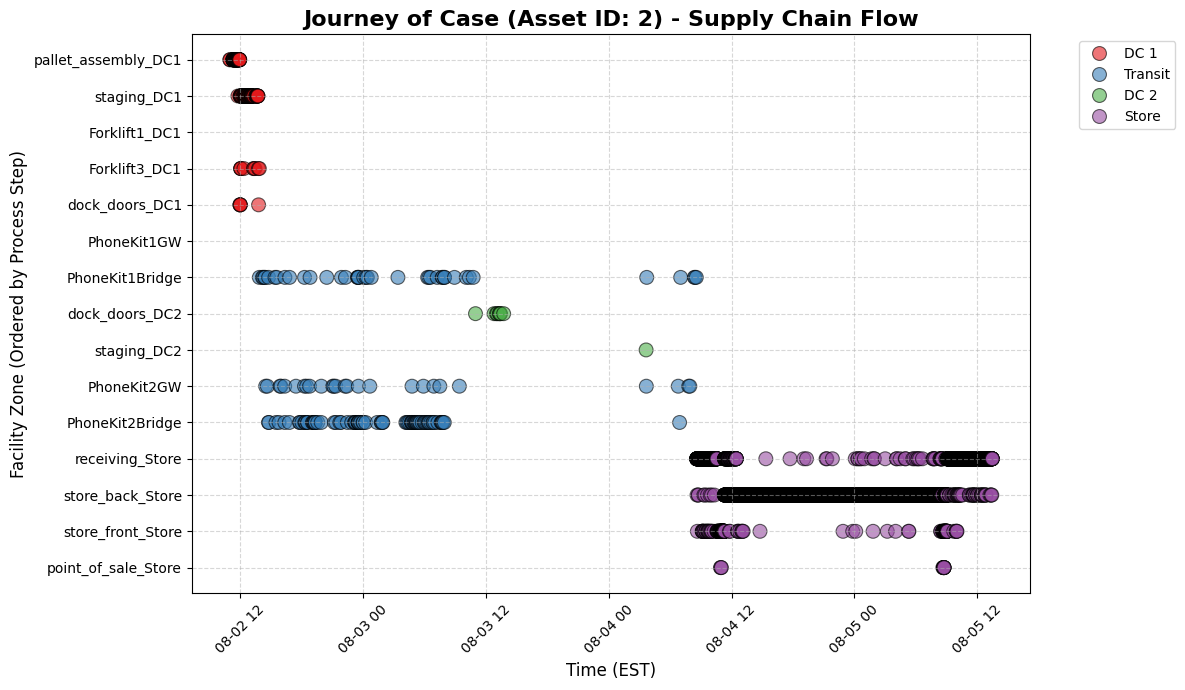

In [4]:
df['time_est'] = pd.to_datetime(df['time_est']) # Convert time_est to datetime
sample_asset = df['asset_id'].unique()[0] # Take the first unique asset_id
df_case = df[df['asset_id'] == sample_asset].sort_values('time_est').copy() #sort chronologically
#df_case.head()

logical_orden = [
    'pallet_assembly_DC1',
    'staging_DC1',
    'Forklift1_DC1',
    'Forklift3_DC1',
    'dock_doors_DC1',
    'PhoneKit1GW',       # Tránsito 1
    'PhoneKit1Bridge',   # Tránsito 1
    'dock_doors_DC2',
    'staging_DC2',
    'PhoneKit2GW',       # Tránsito 2
    'PhoneKit2Bridge',   # Tránsito 2
    'receiving_Store',
    'store_back_Store',
    'store_front_Store',
    'point_of_sale_Store'
]

# Sort the column by categories
df_case['Zone'] = pd.Categorical(df_case['Zone'], categories=logical_orden, ordered=True)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_case,
    x='time_est',
    y='Zone',
    hue='Site',
    s=100,
    alpha=0.6,
    palette='Set1',
    edgecolor='black'
)

plt.title(f'Journey of Case (Asset ID: {sample_asset}) - Supply Chain Flow', fontsize=16, fontweight='bold')
plt.xlabel('Time (EST)', fontsize=12)
plt.ylabel('Facility Zone (Ordered by Process Step)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Question 4:

* Visualize how the temperatue changes over time along its journey.  Imagine that this would be included in your presentation to the customer. (Non techical audience) (4 pts)



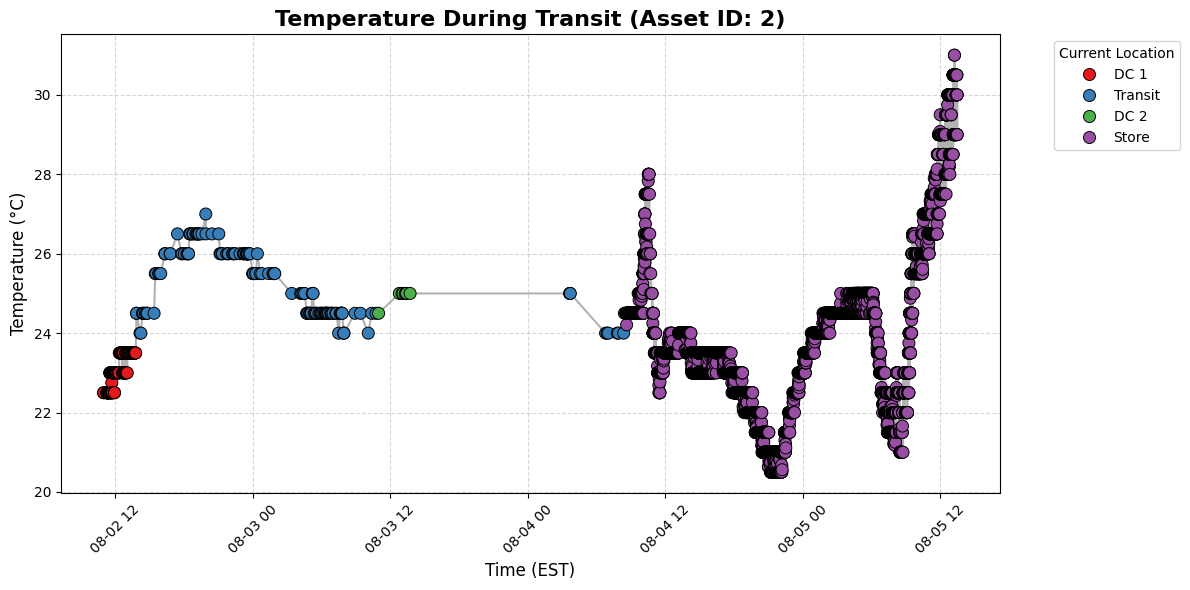

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_case,
    x='time_est',
    y='Temperature_C',
    color='gray',
    linewidth=1.5,
    alpha=0.6,
    zorder=1 #line under points
)
sns.scatterplot(
    data=df_case,
    x='time_est',
    y='Temperature_C',
    hue='Site', # Color according to site
    palette='Set1',
    s=75,
    edgecolor='black',
    zorder=2
)

plt.title(f'Temperature During Transit (Asset ID: {sample_asset})', fontsize=16, fontweight='bold')
plt.xlabel('Time (EST)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Current Location')
plt.tight_layout()

plt.show()

### Question 5:
* Visualize the lon lat data on a map to show how the case traveled.  You may incorporate any other additional information to make this more impactful. Imagine that this would be included in your presentation to the customer. (Non techical audience) (5 pts)

**Do not worry if this looks like non-sense on a map.  Ex:  The trip may appear to occur over water or in a forest because this is a toy dataset.**

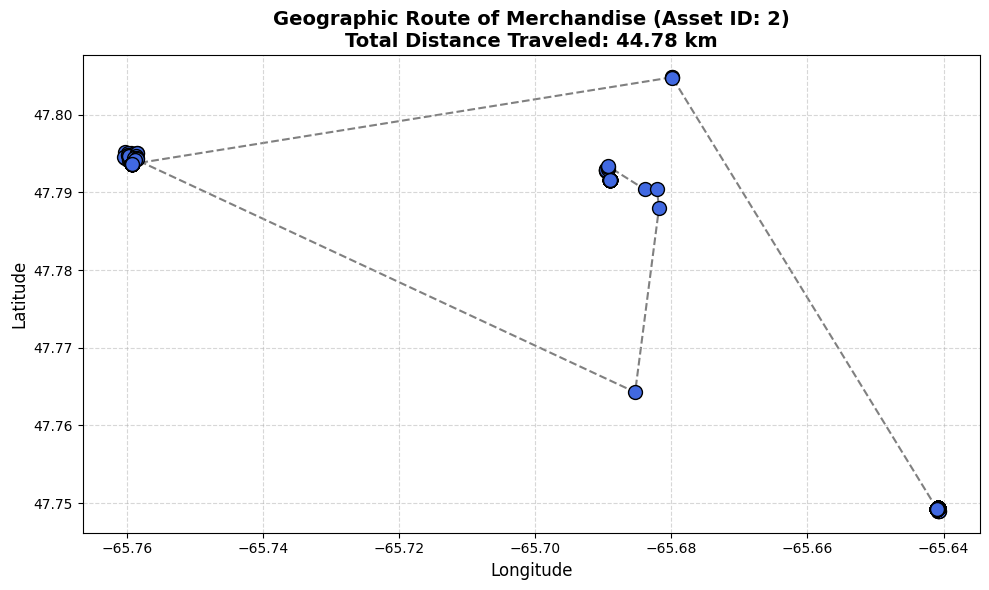

The case traveled a total distance of 44.78 kilometers.


In [6]:
from geopy.distance import geodesic

# Calculate the otal distance traveled
coordinates = list(zip(df_case['lat'], df_case['lng']))
total_distance_km = 0
for i in range(1, len(coordinates)):
    prev_point = coordinates[i-1]
    curr_point = coordinates[i]
    total_distance_km += geodesic(prev_point, curr_point).kilometers

plt.figure(figsize=(10, 6))
plt.plot(df_case['lng'], df_case['lat'], color='gray', linestyle='--', zorder=1)
plt.scatter(df_case['lng'], df_case['lat'], c='royalblue', s=100, edgecolor='black', zorder=2)
plt.title(f'Geographic Route of Merchandise (Asset ID: {sample_asset})\nTotal Distance Traveled: {total_distance_km:.2f} km',
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"The case traveled a total distance of {total_distance_km:.2f} kilometers.")

# Part 3: Customer Questions


### Question 6:

The customer wants to understand the efficieny of ther DC operations.
* Based on what you see in the data, (all zones except for STORE), which parts of their operation are most & least "efficient? (10 pts)

In [7]:
df_dc = df[df['Site'] != 'Store'].copy()# Filter to analyze only DCs and Transit
zone_times = df_dc.groupby(['asset_id', 'Site', 'Zone'])['time_est'].agg(['min', 'max']).reset_index()
zone_times['Duration'] = zone_times['max'] - zone_times['min']
avg_duration = zone_times.groupby(['Site', 'Zone'])['Duration'].mean().sort_values()

print("--- DCs and Transit Efficiency (Average Time per Zone) ---")
print(avg_duration)

--- DCs and Transit Efficiency (Average Time per Zone) ---
Site     Zone               
DC 1     dock_doors_DC1           0 days 00:29:53.899750
         Forklift1_DC1         0 days 00:35:59.673214285
         Forklift3_DC1         0 days 00:54:33.814823529
         pallet_assembly_DC1   0 days 01:20:17.908687500
         staging_DC1           0 days 01:43:12.459388888
Transit  PhoneKit1GW           0 days 06:23:14.353333333
DC 2     dock_doors_DC2        0 days 10:52:12.299083333
         staging_DC2           0 days 12:01:04.005142857
Transit  PhoneKit2Bridge          1 days 13:52:08.779000
         PhoneKit2GW           1 days 16:34:26.398777777
         PhoneKit1Bridge       1 days 17:05:43.494944444
Name: Duration, dtype: timedelta64[ns]


YOUR TEXT ANSWER HERE

Aunque el tiempo promedio más largo ocurre en Tránsito (PhoneKit1Bridge con 22 hrs, lo cual es normal por la logística de transporte), la ineficiencia operativa real está en el DC 2. El proceso más rápido es dock_doors_DC1 (29 min), mientras que el más lento es dock_doors_DC2 (más de 12 horas). Esto indica un problema grave de personal o de gestión de camiones en el segundo almacén.

### Question 7:

The customer wants to understand the stocking efficiency in stores.
* Based on what you see in the data, how quickly did the store unload and stock the merchandise. (5 pts)
* How could this be converted in a KPI that a regional manager could track?  (5 pts)

In [8]:
df_store = df[df['Site'] == 'Store'].copy()

# Find the exact time the asset arrived at the back of the store (Receiving)
arrival = df_store[df_store['Zone'].isin(['receiving_Store', 'store_back_Store'])].groupby('asset_id')['time_est'].min().reset_index()
arrival.rename(columns={'time_est': 'Arrival_Time'}, inplace=True)

# Find the exact time the asset was first detected on the sales floor (Stocked)
stocked = df_store[df_store['Zone'] == 'store_front_Store'].groupby('asset_id')['time_est'].min().reset_index()
stocked.rename(columns={'time_est': 'Stocked_Time'}, inplace=True)

store_kpi = pd.merge(arrival, stocked, on='asset_id')
store_kpi['Unload_to_Stock_Time'] = store_kpi['Stocked_Time'] - store_kpi['Arrival_Time']

print("--- Store Efficiency ---")
print(f"Average time to unload and stock: {store_kpi['Unload_to_Stock_Time'].mean()}")

--- Store Efficiency ---
Average time to unload and stock: 0 days 01:20:24.268277777


YOUR TEXT ANSWER HERE

**Unload and Stock Time:** Según los datos de los sensores, transcurre un promedio de 1 hora y 20 minutos desde que la mercancía llega al área de recepción de la tienda hasta que se encuentra en la sala de ventas (store_front_Store). Esta métrica es altamente eficiente e indica que el personal de la tienda actúa con rapidez para reponer el stock, minimizando la acumulación en el almacén y maximizando la disponibilidad de los productos.

**KPI propuesto para gerentes regionales:** Esta operación se puede estandarizar como un KPI de "Tiempo de llegada a la sala de ventas". Un gerente regional podría realizar un seguimiento de esta métrica en todas las tiendas con el objetivo de mantener el tiempo promedio de llegada a la sala de ventas por debajo de las 2 horas.

### Question 8:

Please explain what you would ask for and what you will do with this data, given that you can talk with the following people (no code needed):


YOUR TEXT ANSWER HERE
* **a. DC 2 Operations Manager**

Lo ​​que solicitaría: Horarios de turnos de los empleados y las horas programadas de llegada y salida de los camiones.

Lo qué haría con estos datos: Cruzaré estos datos operativos con los registros de marcas de tiempo. Esto con el fin de determinar la causa de la estadía prolongada en dock_doors_DC2. La pregunta es si se trata de falta de mano de obra en ciertos turnos para descargar los camiones o hay un conflicto en la programación y hay demasiados camiones llegando simultáneamente.


* **b. Store Manager**

Lo que solicitaría: Los Procedimientos Operativos Estándar (POE) para la recepción de mercancía y el plano arquitectónico de la tienda (específicamente, la ubicación de los sensores de recepción con respecto a las cámaras frigoríficas o las puertas exteriores).

Lo que haría con estos datos: Correlacionar la distribución de la tienda y los POE con las caídas extremas de temperatura observadas al llegar la mercancía para determinar si los productos se almacenan incorrectamente en congeladores durante la hora y veinte minutos que se tarda en reponerlos, o si se exponen a condiciones climáticas adversas, lo que podría comprometer la integridad del producto.

## Part 4: Bonus Insights

### Question 9:

The customer is open to hearing about additional insights you found in the data above and beyond what they asked for.
* Based on what you can see in the data, are there any other interesting insights that the customer may want to hear about? (Up to 15 bonus points)



Durante el análisis exploratorio de los datos, identifiqué dos áreas de oportunidad clave que no estaban explícitamente en las preguntas iniciales, pero que representan un alto valor para las operaciones del cliente:

**1. Anomalías en la cadena de frío**

Al graficar el perfil de temperatura de la mercancía a lo largo del tiempo, detecté que la temperatura se mantiene estable durante el paso por los Centros de Distribución y el Tránsito. Sin embargo, al llegar a la tienda, la mercancía experimenta un picos de calor antes de descender y estabilizarse. Esto sugiere que los pallets están siendo retenidos temporalmente en andenes de descarga sin climatización o expuestos al clima exterior antes de ser ingresados al piso de ventas. Si la mercancía es sensible al calor, la tienda debe optimizar la rapidez con la que ingresan los productos desde la puerta trasera hacia las zonas climatizadas.

**2. Solapamiento de Señal y Ruido de Sensores**

Al observar la densidad de las lecturas en las áreas de transición (por ejemplo, cuando el paquete pasa del camión a la recepción de la tienda), detecté un alto solapamiento de señal. Los sensores de dos zonas distintas registran la misma caja simultáneamente en cuestión de segundos. Esto demuestra que las antenas tienen una potencia excelente, pero representa una oportunidad para aplicar filtros de "suavizado" en el software para eliminar el ruido y tener un registro de ubicación mucho más limpio.
